## _(1) - Processing Stage_

In [1]:
import glob, os, sys, yaml

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
pp = pprint.PrettyPrinter(indent=2)
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _1.1 - Config File_

In [6]:
# load processing config file (trusted source)
config_file = os.path.join(os.curdir, 'LightningModules/Processing/configs/prepare_quickstart.yaml')
with open(config_file) as f:
    try:
        config = yaml.load(f, Loader=yaml.FullLoader) # equiv: yaml.full_load(f)
    except yaml.YAMLError as e:
        print(e)

### _1.2 - Input Data_

In [7]:
input_dir = 'train_all'
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

print("Total Events: ", len(file_prefixes))

Total Events:  10000


In [8]:
# test to load an event
event_prefix = file_prefixes[1]

hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000001 memory usage 0.01 MB


In [9]:
# Fetch an event, use event_id (int)
# prefix = "event{:010d}".format(event_id)                     # make a prefix, OR
# prefix = str('event{!s}'.format(format(event_id, '010d')))   # make a prefix
# INPUT_DATA = os.path.expandvars(config['input_dir'])         # input data directory
# event_prefix = os.path.join(INPUT_DATA, prefix)              # event_prefix ~ event_file = input_dir + prefix
# event = trackml.dataset.load_event(event_prefix)

### _1.3 - Processing_

In [10]:
from src.drawing import detector_layout, draw_proc_event
from src.utils_math import polar_to_cartesian, cylindrical_to_cartesian

In [11]:
# see params used in this stage
# pp.pprint(config)

In [12]:
# change some params here
config['n_files'] = 10
config['train_split'] = [8, 1, 1]
config['regime'] = ['rp', 'hnm']

In [13]:
# see params used in this stage
# pp.pprint(config)

In [14]:
inputdir="run/feature_store"
proc_files = sorted(glob.glob(os.path.join(inputdir, "*")))

In [15]:
event_idx = 1074

In [16]:
feature_data = torch.load(proc_files[event_idx], map_location=device)
print("Length of Data: {}".format(len(feature_data)))

Length of Data: 11


In [17]:
feature_data

Data(x=[184, 3], pid=[184], layers=[184], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001967', hid=[184], pt=[184], modulewise_true_edges=[2, 165], layerwise_true_edges=[2, 583], edge_index=[2, 1329], y=[1329], cell_data=[184, 1])

In [18]:
# x=[r,phi,isochrone]
feature_data.x[:5]

tensor([[0.3770, 0.6453, 0.3500],
        [0.3854, 0.6500, 0.3500],
        [0.3854, 0.6500, 0.3500],
        [0.3861, 0.6417, 0.3500],
        [0.3679, 0.6492, 0.3500]])

In [19]:
feature_data.cell_data[:5]

tensor([[0.0363],
        [0.1106],
        [0.1682],
        [0.4983],
        [0.4510]])

In [20]:
feature_data.edge_index[:5]

tensor([[  0,   0,   0,  ..., 182, 183, 183],
        [  1,   2,   3,  ..., 183, 173, 175]])

In [21]:
feature_data.modulewise_true_edges.shape

torch.Size([2, 165])

In [22]:
feature_data.layerwise_true_edges.shape

torch.Size([2, 583])

In [23]:
feature_data.edge_index.shape

torch.Size([2, 1329])

In [24]:
feature_data.pid.shape

torch.Size([184])

In [25]:
feature_data.y.shape

torch.Size([1329])

In [26]:
feature_data.event_file

'/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001967'

In [27]:
# extract event_id from 'feature_data.event_file'
int(os.path.basename(feature_data.event_file)[-10:])

1967

In [28]:
# event_prefix from 'feature_data'
feature_data.event_file[-15:]

'event0000001967'

In [29]:
# extract 'event_id' from 'feature_data'
int(feature_data.event_file[-10:])

1967

In [30]:
# recreate 'event_prefix' from 'event_id'
event_id = int(feature_data.event_file[-10:])
str('event{!s}'.format(format(event_id, '010d')))

'event0000001967'

In [31]:
# OR, recreate 'event_prefix' from 'event_id'
"event{:010d}".format(1)

'event0000000001'

In [32]:
# get 'event_file' from dirname+event_prefix
os.path.join(os.path.dirname(feature_data.event_file), "event{:010d}".format(1))

'/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000000001'

### _1.4 - Plotting_

### _(+) - Plotting Event_

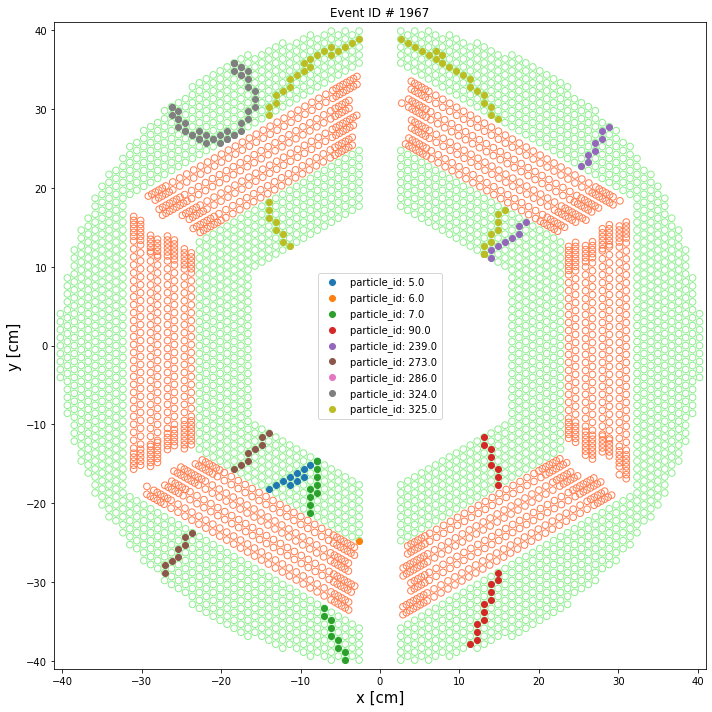

In [33]:
# draw a processed event
draw_proc_event(feature_data, figsize=(10,10), save_fig=False);

### _(+) - Plotting Input Edges_

In [34]:
feature_data

Data(x=[184, 3], pid=[184], layers=[184], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001967', hid=[184], pt=[184], modulewise_true_edges=[2, 165], layerwise_true_edges=[2, 583], edge_index=[2, 1329], y=[1329], cell_data=[184, 1])

In [35]:
# get input_edges (both true & fake)
input_edges = feature_data.edge_index

In [36]:
input_edges[0][:15]

tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2])

In [37]:
input_edges[1][:15]

tensor([  1,   2,   3,  29,  42, 158,   5,   6,   7,  38,  39,   5,   6,   7,
         38])

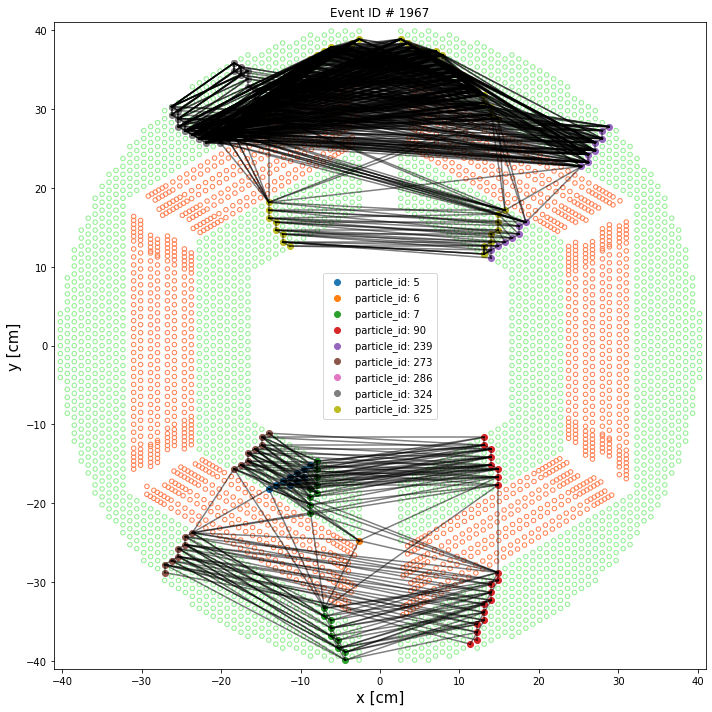

In [38]:
# plotting input_edges
plt.close('all')

# init subplots
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

# detector layout
det = pd.read_csv("src/stt.csv")
skw = det.query('skewed==0')
nkw = det.query('skewed==1') # one may look for +ve/-ve polarity
plt.scatter(skw.x.values, skw.y.values, s=20, facecolors='none', edgecolors='lightgreen')
plt.scatter(nkw.x.values, nkw.y.values, s=20, facecolors='none', edgecolors='coral')

# feature data
x,y,z = cylindrical_to_cartesian(r=feature_data.x[:, 0], phi=feature_data.x[:, 1], z=feature_data.x[:, 2])
    
# particle tracks
p_ids = np.unique(feature_data.pid)
for pid in p_ids:
    idx = feature_data.pid == pid
    ax.scatter(x[idx], y[idx], label='particle_id: %d' %pid)
    
# input edges
for iedge in range(feature_data.edge_index.shape[1]):
#for iedge in range(30):
    ptx1 = x[input_edges[0][iedge]]
    ptx2 = x[input_edges[1][iedge]]
    pty1 = y[input_edges[0][iedge]]
    pty2 = y[input_edges[1][iedge]]
    ax.plot([ptx1, ptx2], [pty1, pty2], color='k', alpha=0.5, lw=1.5)

# plotting params
ax.set_title('Event ID # %d' % event_id)
ax.set_xlabel('x [cm]', fontsize=15)
ax.set_ylabel('y [cm]', fontsize=15)
ax.set_xlim(-41, 41)
ax.set_ylim(-41, 41)
ax.grid(False)
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("input_edges.png")

### _(+) - Plotting True Edges_

In _feature_data_, we have _`layerwise_true_edges`_, _`modulewise_true_edges`_ and _`edge_index`_ (_a.k.a_ input graph). The `edge_index` contains both `true` and `false` edges. However, we have `edge_index` truth as `y` or `y_pid`. So by using `y_pid==1(0)` one can query only `true (false)` edges.

Let's separate true edges:

In [39]:
feature_data.edge_index

tensor([[  0,   0,   0,  ..., 182, 183, 183],
        [  1,   2,   3,  ..., 183, 173, 175]])

In [40]:
# get index of true (false) edges by setting y_pid=True(False)
idx = np.where(feature_data.y==True)[0]

In [41]:
idx.shape

(436,)

In [42]:
# get true edges equiv to layerwise_true_edges
input_edges = feature_data.edge_index.T[idx].T

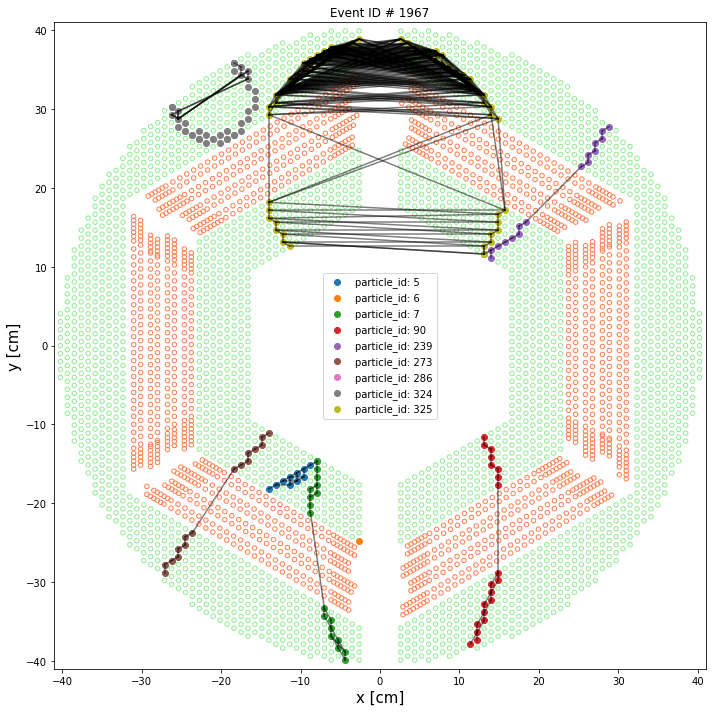

In [43]:
# plotting input_edges
plt.close('all')

# init subplots
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

# detector layout
det = pd.read_csv("src/stt.csv")
skw = det.query('skewed==0')
nkw = det.query('skewed==1') # one may look for +ve/-ve polarity
plt.scatter(skw.x.values, skw.y.values, s=20, facecolors='none', edgecolors='lightgreen')
plt.scatter(nkw.x.values, nkw.y.values, s=20, facecolors='none', edgecolors='coral')

# feature data
x,y,z = cylindrical_to_cartesian(r=feature_data.x[:, 0], phi=feature_data.x[:, 1], z=feature_data.x[:, 2])
    
# particle tracks
p_ids = np.unique(feature_data.pid)
for pid in p_ids:
    idx = feature_data.pid == pid
    ax.scatter(x[idx], y[idx], label='particle_id: %d' %pid)
    
# input edges
for iedge in range(input_edges.shape[1]):
#for iedge in range(56):
    ptx1 = x[input_edges[0][iedge]]
    ptx2 = x[input_edges[1][iedge]]
    pty1 = y[input_edges[0][iedge]]
    pty2 = y[input_edges[1][iedge]]
    ax.plot([ptx1, ptx2], [pty1, pty2], color='k', alpha=0.5, lw=1.5)

# plotting params
ax.set_title('Event ID # %d' % event_id)
ax.set_xlabel('x [cm]', fontsize=15)
ax.set_ylabel('y [cm]', fontsize=15)
ax.set_xlim(-41, 41)
ax.set_ylim(-41, 41)
ax.grid(False)
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("true_edges.png")

### _(+) - Plotting False Edges_

In _feature_data_, we have _`layerwise_true_edges`_, _`modulewise_true_edges`_ and _`edge_index`_ (_a.k.a_ input graph). The `edge_index` contains both `true` and `false` edges. However, we have `edge_index` truth as `y` or `y_pid`. So by using `y_pid==1(0)` one can query only `true (false)` edges.

Let's separate false edges:

In [44]:
# get index of true (false) edges by setting y_pid=True(False)
idx = np.where(feature_data.y==False)[0]

In [45]:
idx.shape

(893,)

In [46]:
# get true edges equiv to layerwise_true_edges
input_edges = feature_data.edge_index.T[idx].T

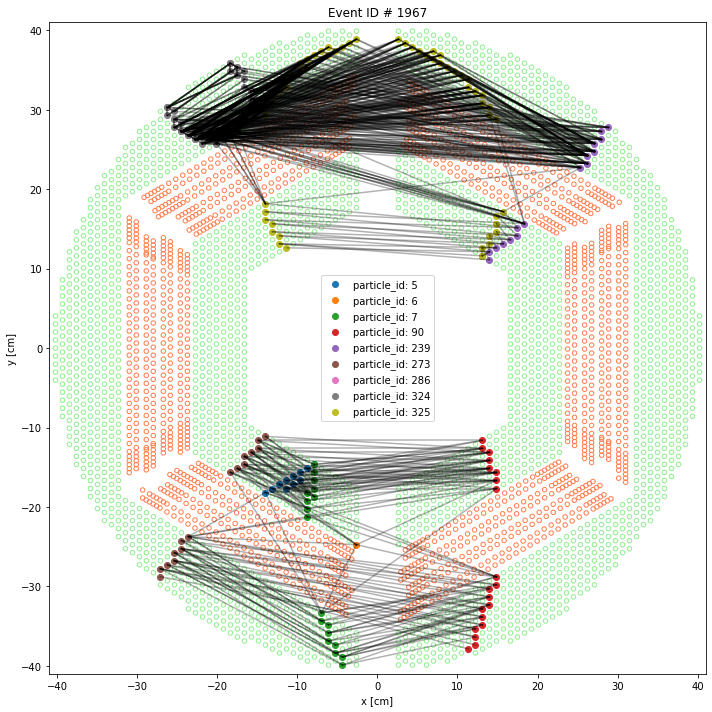

In [47]:
# plotting input_edges
plt.close('all')

# init subplots
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

# detector layout
det = pd.read_csv("src/stt.csv")
skw = det.query('skewed==0')
nkw = det.query('skewed==1') # one may look for +ve/-ve polarity
plt.scatter(skw.x.values, skw.y.values, s=20, facecolors='none', edgecolors='lightgreen')
plt.scatter(nkw.x.values, nkw.y.values, s=20, facecolors='none', edgecolors='coral')

# feature data
x,y,z = cylindrical_to_cartesian(r=feature_data.x[:, 0], phi=feature_data.x[:, 1], z=feature_data.x[:, 2])
    
# particle tracks
p_ids = np.unique(feature_data.pid)
for pid in p_ids:
    idx = feature_data.pid == pid
    ax.scatter(x[idx], y[idx], label='particle_id: %d' %pid)
    
# input edges
for iedge in range(input_edges.shape[1]):
#for iedge in range(56):
    ptx1 = x[input_edges[0][iedge]]
    ptx2 = x[input_edges[1][iedge]]
    pty1 = y[input_edges[0][iedge]]
    pty2 = y[input_edges[1][iedge]]
    ax.plot([ptx1, ptx2], [pty1, pty2], color='k', alpha=0.3, lw=1.5)

# plotting params
ax.set_title('Event ID # %d' % event_id)
ax.set_xlabel('x [cm]', fontsize=10)
ax.set_ylabel('y [cm]', fontsize=10)
ax.set_xlim(-41, 41)
ax.set_ylim(-41, 41)
ax.grid(False)
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("input_edges.png")

### _Alternate to Plotting True and False Edges_

- code from `notebooks/example_gnn.ipynb`

In [48]:
from src.utils_math import polar_to_cartesian

In [49]:
# get spatial coordinates, note: x = [x,y,ir]
r, phi, ir = feature_data.x.T

In [50]:
# coordinate transform
x, y = polar_to_cartesian(r, phi)

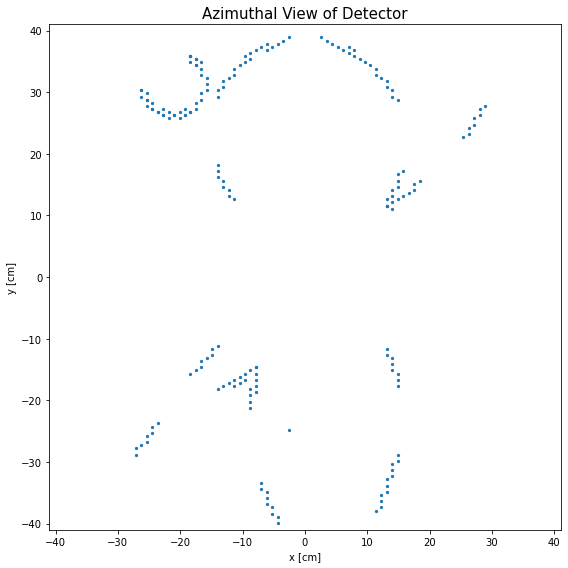

In [51]:
# plot all hits
plt.close('all')
plt.figure(figsize=(8, 8))

plt.scatter(x, y, s=5)

plt.title("Azimuthal View of Detector", fontsize=15)
plt.xlabel("x [cm]", fontsize=10)
plt.ylabel("y [cm]", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim((-41, 41))
plt.ylim((-41, 41))
plt.grid(False)
plt.tight_layout()

In [52]:
# get true_edges
e = feature_data.edge_index
pid = feature_data.pid
true_edges = pid[e[0]] == pid[e[1]]

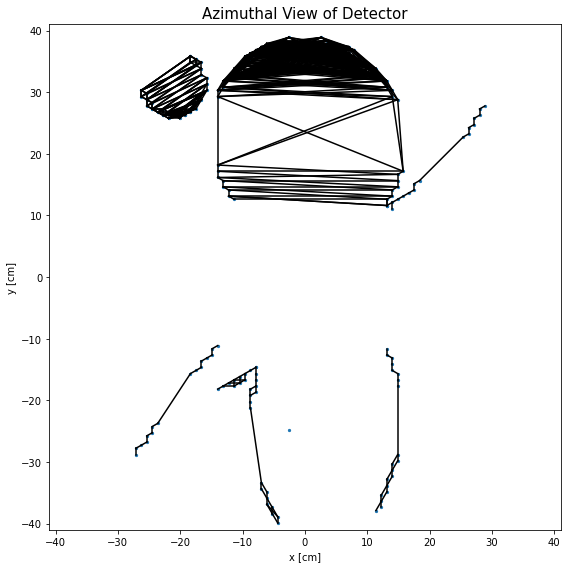

In [53]:
# plot only true edges
plt.close('all')
plt.figure(figsize=(8,8))

plt.plot(x[e[:, true_edges]], y[e[:, true_edges]], c="k")
plt.scatter(x, y, s=5)

plt.title("Azimuthal View of Detector", fontsize=15)
plt.xlabel("x [cm]", fontsize=10)
plt.ylabel("y [cm]", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim((-41, 41))
plt.ylim((-41, 41))
plt.grid(False)
plt.tight_layout()

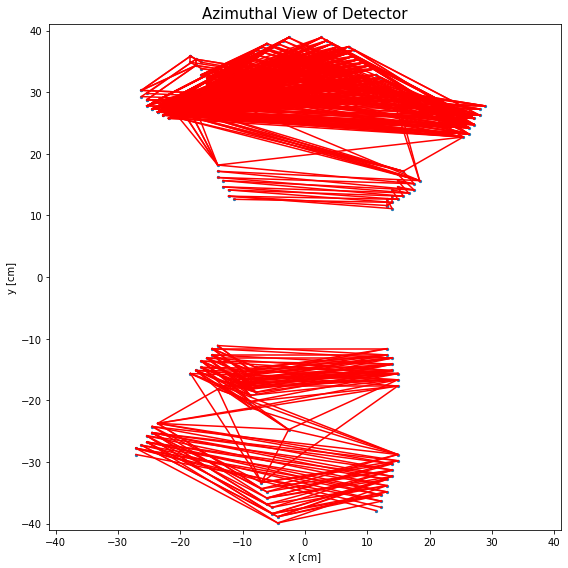

In [54]:
# plot only false edges
plt.close('all')
plt.figure(figsize=(8,8))

plt.scatter(x, y, s=5)
plt.plot(x[e[:, ~true_edges]], y[e[:, ~true_edges]], c="r")


plt.title("Azimuthal View of Detector", fontsize=15)
plt.xlabel("x [cm]", fontsize=10)
plt.ylabel("y [cm]", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim((-41, 41))
plt.ylim((-41, 41))
plt.grid(False)
plt.tight_layout()

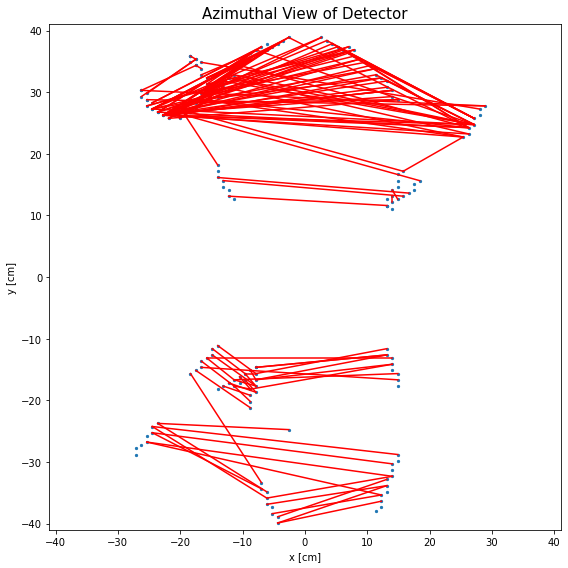

In [55]:
# plot all edges (true + false), only few false edges
plt.close('all')
plt.figure(figsize=(8,8))

plt.plot(x[e[:, (~true_edges)][:, 0:-1:5]], y[e[:, (~true_edges)][:, 0:-1:5]], c="r")
plt.scatter(x, y, s=5)

plt.title("Azimuthal View of Detector", fontsize=15)
plt.xlabel("x [cm]", fontsize=10)
plt.ylabel("y [cm]", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim((-41, 41))
plt.ylim((-41, 41))
plt.grid(False)
plt.tight_layout()